
Congrats....again! Based off the amazing work you did on the classification model, you've been promoted to chief of all data scientists in Hollywood, your a total celebrity....among data scientists :).  

Your boss, head of the studio, has now asked you to build a model to predict gross revenue in order to help them decide which movies to invest in.

Once again, you would like to be able to explain the model to mere mortals but need a fairly robust and flexible approach so you've chosen to use decision trees to get started. 

In doing so...you leverage work you've done in the past to get the job done....you're a data scientist after all! 

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split as tts
import matplotlib.pyplot as plt
import graphviz 

from sklearn.model_selection import RepeatedKFold,GridSearchCV
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor, export_graphviz 

In [3]:
#1. Load the data
movie_metadata=pd.read_csv("/workspaces/DS-3021/data/movie_metadata.csv")

#2-4 Data prep/cleaning
* Ensure all the variables are classified correctly including the target variable and collapse factor variables as needed.
* Check for missing variables and correct as needed.

In [4]:
def movie_cleaning(data):
    movies = data[['duration', 'genres', 'gross', 'content_rating', 'budget', 'cast_total_facebook_likes', 'imdb_score', 'country']]
    genres = ['Action', 'Drama', 'Comedy', 'Romance', 'Horror', 'Thriller', 
              'Adventure', 'Fantasy', 'Sci-Fi', 'Animation', 'Documentary', 
              'Family', 'Mystery', 'Western', 'Crime', 'Music', 'War', 'History', 
              'Sport', 'Short', 'Biography']
    for genre in genres:
        movies[genre] = 0
    for index, row in movies.iterrows():
        for genre in genres:
            if genre in row['genres']:
                movies.loc[index, genre] = 1
    movies = movies.drop(columns=['genres'])
    movies = movies.dropna()
    movies = movies[movies['budget'] < 3500000000]
    movies = movies[movies['cast_total_facebook_likes'] < 320000]
    movies_encoded = pd.get_dummies(movies, columns=['content_rating']) 
    #remove columns with extremely low prevalence
    smallprevs = ['Short', 'Documentary', 'War', 'History', 'Biography', 'Music', 'Western', 'Sport', 'Animation', 
                  'content_rating_Approved', 'content_rating_G', 'content_rating_GP', 'content_rating_M',
                  'content_rating_NC-17', 'content_rating_Passed', 'content_rating_Unrated', 'content_rating_X', 
                  'content_rating_Not Rated']
    movies_encoded = movies_encoded.drop(columns=smallprevs)
    return movies_encoded 

pd.options.mode.chained_assignment = None  # default='warn'
movs = movie_cleaning(movie_metadata)
movs

,duration,gross,budget,cast_total_facebook_likes,imdb_score,country,Action,Drama,Comedy,Romance,...,Thriller,Adventure,Fantasy,Sci-Fi,Family,Mystery,Crime,content_rating_PG,content_rating_PG-13,content_rating_R
0,178.0,760505847.0,237000000.0,4834,7.9,USA,1,0,0,0,...,0,1,1,1,0,0,0,False,True,False
1,169.0,309404152.0,300000000.0,48350,7.1,USA,1,0,0,0,...,0,1,1,0,0,0,0,False,True,False
2,148.0,200074175.0,245000000.0,11700,6.8,UK,1,0,0,0,...,1,1,0,0,0,0,0,False,True,False
3,164.0,448130642.0,250000000.0,106759,8.5,USA,1,0,0,0,...,1,0,0,0,0,0,0,False,True,False
5,132.0,73058679.0,263700000.0,1873,6.6,USA,1,0,0,0,...,0,1,0,1,0,0,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5033,77.0,424760.0,7000.0,368,7.0,USA,0,1,0,0,...,1,0,0,1,0,0,0,False,True,False
5034,80.0,70071.0,7000.0,0,6.3,Philippines,0,0,0,0,...,1,0,0,0,0,0,0,False,False,False
5035,81.0,2040920.0,7000.0,147,6.9,USA,1,1,0,1,...,1,0,0,0,0,0,1,False,False,True
5037,95.0,4584.0,9000.0,690,6.4,USA,0,1,1,0,...,0,0,0,0,0,0,0,False,False,False


In [5]:
for row in movs.itertuples():
    if row.country == 'USA':
        movs.at[row.Index, 'country'] = 1
    elif row.country == 'UK':
        movs.at[row.Index, 'country'] = 2
    elif row.country == 'France':
        movs.at[row.Index, 'country'] = 3
    else:
        movs.at[row.Index, 'country'] = 4
movs['country'] = movs['country'].astype(int)
movs.head()

,duration,gross,budget,cast_total_facebook_likes,imdb_score,country,Action,Drama,Comedy,Romance,...,Thriller,Adventure,Fantasy,Sci-Fi,Family,Mystery,Crime,content_rating_PG,content_rating_PG-13,content_rating_R
0,178.0,760505847.0,237000000.0,4834,7.9,1,1,0,0,0,...,0,1,1,1,0,0,0,False,True,False
1,169.0,309404152.0,300000000.0,48350,7.1,1,1,0,0,0,...,0,1,1,0,0,0,0,False,True,False
2,148.0,200074175.0,245000000.0,11700,6.8,2,1,0,0,0,...,1,1,0,0,0,0,0,False,True,False
3,164.0,448130642.0,250000000.0,106759,8.5,1,1,0,0,0,...,1,0,0,0,0,0,0,False,True,False
5,132.0,73058679.0,263700000.0,1873,6.6,1,1,0,0,0,...,0,1,0,1,0,0,0,False,True,False


#5 Determine the range and variance of the target variable.

In [6]:
variance = movs['gross'].var()
print(f"Variance in gross: {variance}")
range = movs['gross'].max() - movs['gross'].min()
print(f"Range in gross: {range}")

Variance in gross: 4905373108137447.0
Range in gross: 760505685.0


Text(0.5, 1.0, 'Distribution of Gross Revenue')

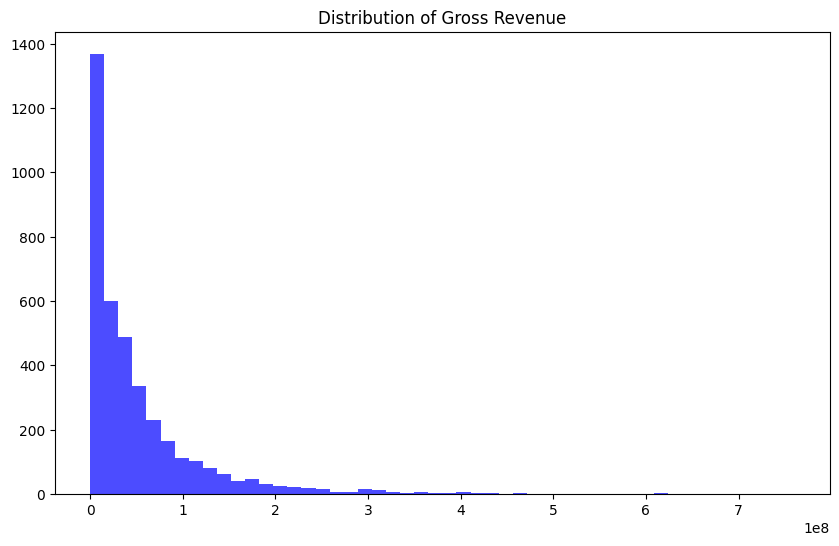

In [7]:
#print the distribution of the target variable 'gross'
plt.figure(figsize=(10, 6))
plt.hist(movs['gross'], bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Gross Revenue')
#this looks pretty skewed, let's log transform it

Text(0.5, 1.0, 'Distribution of Log(Gross Revenue)')

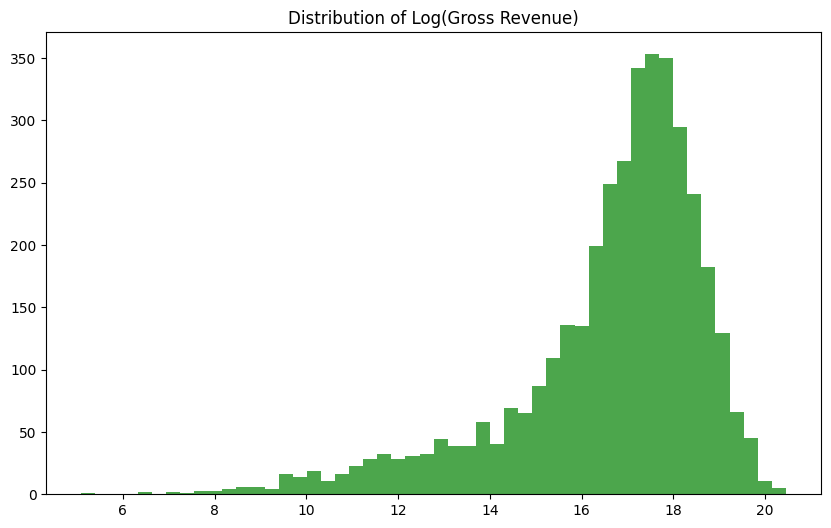

In [8]:
#this looks pretty skewed, let's try some transformations
movs['log_gross'] = np.log(movs['gross'] + 1) #add 1 to avoid log(0)
plt.figure(figsize=(10, 6))
plt.hist(movs['log_gross'], bins=50, color='green', alpha=0.7)
plt.title('Distribution of Log(Gross Revenue)')
#log still looks a bit skewed

Text(0.5, 1.0, 'Distribution of Yeo-Johnson Transformed Gross Revenue')

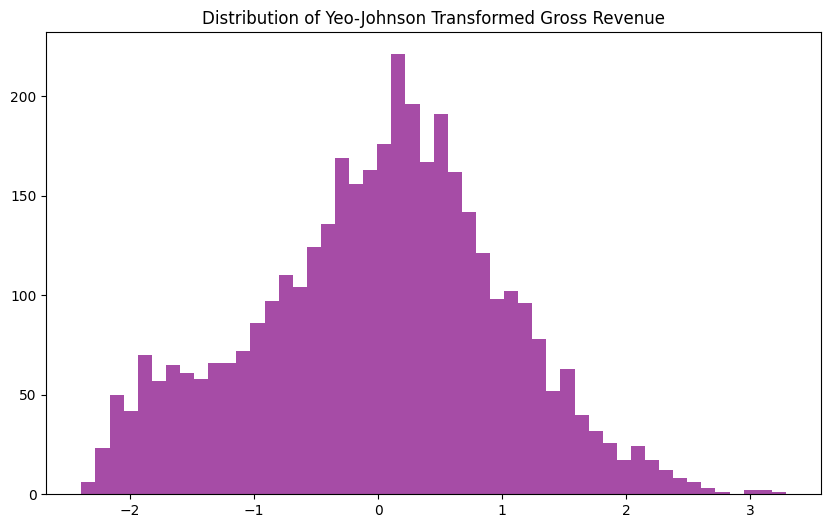

In [9]:
from sklearn.preprocessing import PowerTransformer

# Apply Yeo-Johnson transformation
pt = PowerTransformer(method='yeo-johnson')
movs['yeojohnson_gross'] = pt.fit_transform(movs[['gross']])
plt.figure(figsize=(10, 6))
plt.hist(movs['yeojohnson_gross'], bins=50, color='purple', alpha=0.7,)
plt.title('Distribution of Yeo-Johnson Transformed Gross Revenue')
# The Yeo-Johnson transformation makes the distribution more normal-like

In [10]:
movs = movs.drop(columns=['gross', 'log_gross']) 

In [11]:
# and now lets check out the updated variance and range
variance = movs['yeojohnson_gross'].var()
print(f"Variance in Yeo-Johnson gross: {variance}")
range = movs['yeojohnson_gross'].max() - movs['yeojohnson_gross'].min()
print(f"Range in Yeo-Johnson gross: {range}")

Variance in Yeo-Johnson gross: 1.0002606882168925
Range in Yeo-Johnson gross: 5.6756918797332965


{'whiskers': [<matplotlib.lines.Line2D at 0x7f86b9c22d20>,
 'caps': [<matplotlib.lines.Line2D at 0x7f86b9afcc20>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f86b9afc3b0>],
 'medians': [<matplotlib.lines.Line2D at 0x7f86b9afd190>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f86b9afd310>],
 'means': []}

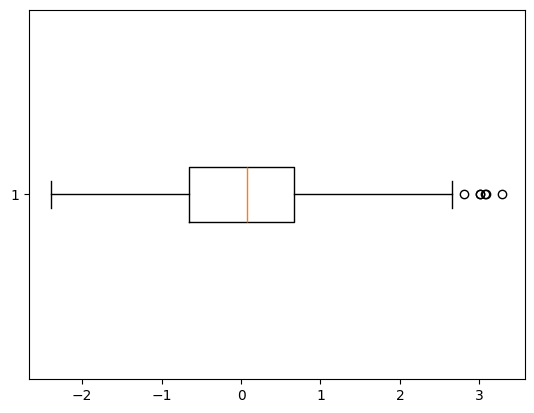

In [12]:
plt.boxplot(movs['yeojohnson_gross'], vert=False)

#6 Split your data into test, tune, and train. (80/10/10)

In [13]:
Train, Test = tts(movs, test_size=0.2, random_state=42)
Test, Tune = tts(Test, test_size=0.5, random_state=42) 
# Separate features and target variable for training and testing
X_train = Train.drop(columns=['yeojohnson_gross'])
y_train = Train['yeojohnson_gross']
X_test = Test.drop(columns=['yeojohnson_gross'])
y_test = Test['yeojohnson_gross']
X_tune = Tune.drop(columns=['yeojohnson_gross'])
y_tune = Tune['yeojohnson_gross']
# Check the shapes of the datasets
print(f"Training set shape: {X_train.shape}, Target shape: {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, Target shape: {y_test.shape}")
print(f"Tuning set shape: {X_tune.shape}, Target shape: {y_tune.shape}")


Training set shape: (3069, 20), Target shape: (3069,)
Testing set shape: (384, 20), Target shape: (384,)
Tuning set shape: (384, 20), Target shape: (384,)


#7 Create the kfold object for cross validation.

In [14]:
kf =RepeatedKFold(n_splits=10,n_repeats =5, random_state=42)

#8 Create the scoring metric (several measures) you will use to evaluate your model and the min samples leaf hyperparameter.

In [15]:
scoring= ['neg_mean_squared_error','r2','neg_mean_absolute_error']

#param={"min_samples_leaf":[5,15,25,35,45,55]}
param = {"max_depth" : [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]}

#9 Build the regression tree object. 

In [16]:
reg=DecisionTreeRegressor(random_state=30)

#10-12 using grid search, fitting the model, and variable importance

In [17]:
search = GridSearchCV(reg, param, scoring=scoring, n_jobs=-1, cv=kf,refit='r2')

In [18]:
model = search.fit(X_train, y_train)

In [19]:
best = model.best_estimator_
print("Best parameters found: ", model.best_params_)

Best parameters found:  {'max_depth': 5}


#13 View the results, comment on how the model performed using several evaluation metrics.

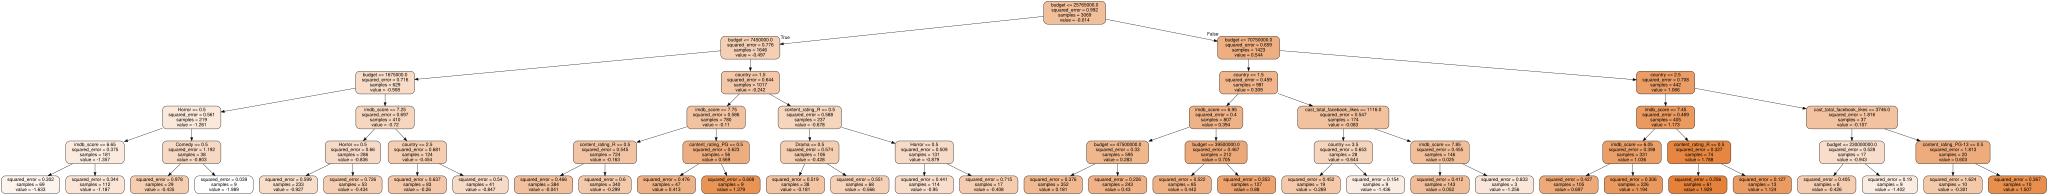

In [20]:
#Plotting the decision tree for the best estimator 
dot_data = export_graphviz(best, out_file =None,
               feature_names =X_train.columns, #feature names from dataset
               filled=True, 
                rounded=True, ) 
               
graph=graphviz.Source(dot_data)
graph #Pretty big, it is a continuous target afterall.

In [27]:
y_pred = best.predict(X_train)
rmse = (metrics.mean_squared_error(y_train, y_pred))**0.5
print(f"Mean Squared Error on Train Set: {rmse}")
r2 = metrics.r2_score(y_train, y_pred)
print(f"R^2 Score on Train Set: {r2}")


Mean Squared Error on Train Set: 0.6694055329738087
R^2 Score on Train Set: 0.548155933453321


In [22]:
#Let's extract these scores based on depth!

#Scores: 

#Have negative mean squared error so need to take absolute value and square root to convert to root mean squared error
mean_sq_err = np.sqrt(abs(model.cv_results_['mean_test_neg_mean_squared_error']))
#nothing needs to be done for r2, it is the same
r2= model.cv_results_['mean_test_r2']
#Have negative mean absolute error so need to take absolute value
mae= abs(model.cv_results_['mean_test_neg_mean_absolute_error'])

#Parameter:
depth= np.unique(model.cv_results_['param_max_depth']).data

#Build DataFrame:
final_model = pd.DataFrame(list(zip(depth, mean_sq_err, r2,mae)),
               columns =['depth','rmse','r2','mae'])

#Let's take a look
final_model

,depth,rmse,r2,mae
0,1,0.850291,0.268459,0.680780
1,2,0.786182,0.374320,0.615039
2,3,0.753976,0.424583,0.589882
3,4,0.737667,0.449123,0.576575
4,5,0.724981,0.468022,0.563944
5,6,0.726266,0.466032,0.561192
6,7,0.728912,0.461959,0.561114
7,8,0.745841,0.436554,0.570203
8,9,0.765437,0.406531,0.583577
9,10,0.794156,0.360902,0.603140


The root mean squared error for our best model(depth 5) is 0.72. Given that the range in our target variable is about 5.6, this suggests that model is performing somewhat well. It's not great at predicting the exact gross revenue, but it is providing a reasonable estimate within the range of values.

The best r2 value, 0.46, tells a similar story. The correlation isn't super strong or precise, but the model is capturing a weaker trend in gross revenue.

Also, looking at the colors encoded in the visualization of the decision tree, we can see that the majority of nodes have somewhat large squared errors. Only a couple nodes have a dark color and low error. This suggests that for certain types of movies it's really good, but for most it's just mediocre.

In [23]:
varimportances = best.feature_importances_
importances = pd.DataFrame({'feature': X_train.columns, 'importance': varimportances})
importances = importances.sort_values(by='importance', ascending=False)
importances

,feature,importance
1,budget,0.742615
4,country,0.098505
3,imdb_score,0.080073
2,cast_total_facebook_likes,0.019478
19,content_rating_R,0.018513
9,Horror,0.014690
7,Comedy,0.009939
18,content_rating_PG-13,0.009796
17,content_rating_PG,0.004224
6,Drama,0.002166


It looks like budget, by far is contributing the most! This makes sense, because the high budget blockbusters tend to be more successful.

#13 Create a model object using the best model hyperparameter value from the trained regression tree. 

I created this object earlier, it is called "best"

#14 Using the best model predict on the tune data and print out the results.

In [24]:
tune_pred = best.predict(X_tune)
tune_pred

array([-1.18704619,  1.19372212, -0.29946016,  1.19372212,  1.19372212,
       -0.92726427, -0.92726427, -0.29946016, -0.0413853 ,  1.37928698,
        0.181143  , -0.43362585,  0.181143  ,  0.181143  , -0.56602674,
        0.41335074, -0.43362585, -0.29946016,  0.181143  ,  0.41335074,
       -0.0413853 , -0.56602674, -0.18104574, -0.0413853 ,  0.69714308,
       -0.18104574, -1.18704619, -0.43362585,  0.69714308, -0.92726427,
       -0.29946016, -0.0413853 ,  0.41335074,  0.42989329, -0.0413853 ,
       -0.29946016,  0.42989329, -1.2563858 , -0.29946016,  0.05202604,
        0.42989329,  1.19372212,  0.181143  ,  0.69714308, -0.40775271,
        1.19372212, -0.0413853 , -0.43495573,  0.181143  ,  0.44227884,
       -0.0413853 ,  0.42989329, -0.0413853 , -0.29946016, -0.40775271,
        0.05202604, -0.0413853 , -0.43362585,  0.42989329, -0.30071976,
        0.05202604,  1.19372212,  0.181143  , -0.0413853 , -0.56602674,
       -0.43362585,  0.42989329, -1.18704619,  0.69714308, -0.56

#15 How does the model perform on the tune data as compared to the training data?

In [28]:
rmse = (metrics.mean_squared_error(y_tune, tune_pred))**0.5
print(f"root Mean Squared Error on Tune Set: {rmse}")
r2 = metrics.r2_score(y_tune, tune_pred)
print(f"R^2 Score on Tune Set: {r2}")

root Mean Squared Error on Tune Set: 0.7329566060903686
R^2 Score on Tune Set: 0.4922519800831828


On the training data, it was 0.67 for the rmse and 0.55 for the r squared value. The RMSE was a little bit higher on the tune set, and the R squared value was a little bit lower. The model performed similarly but slightly worse. This is pretty reasonable.

#16 What five movies are predicted to have the lowest gross revenue from the tune set?

In [49]:
# Store the original indexes of the Tune set
tune_indexes = X_tune.index

# Make predictions
tune_pred = best.predict(X_tune)

# Create a DataFrame or Series with predictions and align with original indexes
tune_pred_df = pd.DataFrame(tune_pred, index=tune_indexes, columns=['predicted_yj_gross'])
# add new column
tune_pred_df['pred_yj_inv'] = pt.inverse_transform(tune_pred_df[['predicted_yj_gross']].to_numpy())

# sort the dataframe
tune_pred_df = tune_pred_df.sort_values(by='pred_yj_inv', ascending=True)
tune_pred_df.head(10)

/workspaces/DS-3021/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


,predicted_yj_gross,pred_yj_inv
4964,-1.988720,4.597969e+04
4866,-1.632940,3.664625e+05
4863,-1.632940,3.664625e+05
4817,-1.632940,3.664625e+05
4712,-1.632940,3.664625e+05
4424,-1.632940,3.664625e+05
4923,-1.632940,3.664625e+05
2296,-1.436066,8.263683e+05
1601,-1.256386,1.540260e+06
1714,-1.256386,1.540260e+06


now, we can use these indexes to look back at the title of the movie from the original dataframe

In [53]:
for index in [4964, 4866, 4863, 4817, 4712]:
    print(movie_metadata.iloc[index]['movie_title'])

Cheap Thrills 
Sugar Town 
November 
American Ninja 2: The Confrontation 
Broken Vessels 


Haven't heard of any of these movies, but they are predicted to have the lowest gross revenue!

#17 As a data scientist you are always looking to improve your results. What are some ideas you have to improve the model? Have you ask...WHAT IF?!

* maybe the Yeo-Johnson transformation was not the best choice for the target variable, I could try another one
* If i took the budget component out of the model, maybe other variables could point me in a better direction
* Since gross revenue has to do with popularity, maybe including more facebook likes variables in the training would help it improve
* What if content rating isn't very important in determining gross revenue? I could try removing it from the model
* What if I made imdb score a categorical variable instead of a continuous one?

#18 Experiment using your what if ideas (two is fine). Did the model improve? If so, how much? If not, what did you learn? (You don't need to include all the "what if" code just speak to what you tried and what you learned)

I'm going to remove budget, and make imdb score a categorical variable

In [55]:
new_movs = movs.drop(columns=['budget'])

In [57]:
for row in new_movs.itertuples():
    if row.imdb_score < 2.5:
        new_movs.at[row.Index, 'imdb_score'] = 1
    elif row.imdb_score < 5.0:
        new_movs.at[row.Index, 'imdb_score'] = 2
    elif row.imdb_score < 7.5:
        new_movs.at[row.Index, 'imdb_score'] = 3
    else:
        new_movs.at[row.Index, 'imdb_score'] = 4
new_movs['imdb_score'] = new_movs['imdb_score'].astype('category')

In [58]:
Train, Test = tts(new_movs, test_size=0.2, random_state=42)
Test, Tune = tts(Test, test_size=0.5, random_state=42)
X_train = Train.drop(columns=['yeojohnson_gross'])
y_train = Train['yeojohnson_gross']
X_test = Test.drop(columns=['yeojohnson_gross'])
y_test = Test['yeojohnson_gross']
X_tune = Tune.drop(columns=['yeojohnson_gross'])
y_tune = Tune['yeojohnson_gross']
kf = RepeatedKFold(n_splits=10, n_repeats=5, random_state=42)
scoring= ['neg_mean_squared_error','r2','neg_mean_absolute_error']
param = {"max_depth" : [1,2,3,4,5,6,7,8,9,10,11]}
reg=DecisionTreeRegressor(random_state=30)
search = GridSearchCV(reg, param, scoring=scoring, n_jobs=-1, cv=kf, refit='r2')
model = search.fit(X_train, y_train)

In [ ]:
best = model.best_estimator_
train_pred = best.predict(X_train)
rmse = (metrics.mean_squared_error(y_train, train_pred))**0.5
print(f"Root Mean Squared Error on Train Set: {rmse}")
r2 = metrics.r2_score(y_train, train_pred)
print(f"R^2 Score on Train Set: {r2}")

Mean Squared Error on Train Set: 0.7944786336680986
R^2 Score on Train Set: 0.36353513778145696


The RMSE got higher and the rsquared value got lower, meaning the model got worse. I learned that budget should definitely be included, as should the variance in imdb score.

#19 Use the best model to predict on the test data and print out the evaluation results.

In [ ]:
test_pred = best.predict(X_test)
rmse = (metrics.mean_squared_error(y_test, test_pred))**0.5
print(f"root Mean Squared Error on Test Set: {rmse}")
r2 = metrics.r2_score(y_test, test_pred) 
print(f"R^2 Score on Test Set: {r2}")

root Mean Squared Error on Test Set: 0.8182688037796862
R^2 Score on Test Set: 0.33052919848340434


#20 Does the model perform well on the test data when compared to the training and tune data? Why or why not?

It performs pretty much the same. This suggests that the model isn't overfitting, which is good.

#21 Where are the errors occurring in your predictions? Are they systematic or random? In either case, what are the implications of this?

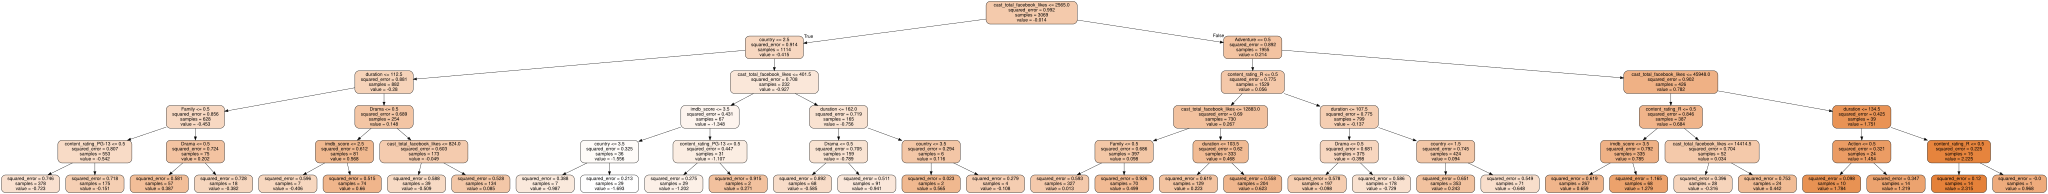

In [61]:
#to check this out, i made a visualization of my tweaked model
dot_data = export_graphviz(best, out_file=None,
               feature_names=X_train.columns,
               filled=True, 
                rounded=True, )
graph = graphviz.Source(dot_data)
graph

Looking at the colors encoded in this decision tree, it looks like my model is making the most errors when predicting lower Yeo-Johnson gross revenue values. This is a systematic error, and it suggests that the model is not very good at predicting low gross revenue movies. The inverse is also true, suggesting that the error is indeed systematic.

#22 Summarize what you learned along the way and make recommendations on how this could be used moving forward, being careful not to over promise.

Both the models I made were strongest at predicting movies that had higher gross revenue. As a result, I would only advise using this model to pick out top-selling movies, and not to use it when looking at lower or mid-tier movies. It might be okay at identifying the general area a movie will fall into, but it won't be able to give you a precise estimate.

I learned that budget goes a long way in determining gross revenue.